In [6]:
# =====================================
# STEP 0 — IMPORT LIBRARIES
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [7]:
# =====================================
# STEP 0 — IMPORT LIBRARIES
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [8]:
# =====================================
# STEP 2 — CLEAN COLUMN NAMES
# =====================================

df.columns = df.columns.str.strip()

In [9]:
# =====================================
# STEP 3 — HANDLE MISSING VALUES
# =====================================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Fill numeric with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# =====================================
# STEP 4 — DROP ID COLUMN
# =====================================

df = df.drop(columns=["Order_ID"])

In [11]:
# =====================================
# STEP 5 — ENCODE CATEGORICAL FEATURES
# =====================================

df = pd.get_dummies(df, drop_first=True)

In [12]:
# =====================================
# STEP 6 — DEFINE TARGET
# =====================================

target = "Delivery_Time"

X = df.drop(columns=[target])
y = df[target]

In [13]:
# =====================================
# STEP 7 — TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
# =====================================
# STEP 8 — FEATURE SCALING
# =====================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# =====================================
# STEP 9 — LINEAR REGRESSION
# =====================================

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("📊 Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

📊 Linear Regression
R2 Score: -0.02657974559416032
RMSE: 30.81354543843704
MAE: 25.848934683929986


In [16]:
# =====================================
# STEP 10 — NEURAL NETWORK
# =====================================

param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64)],
    'learning_rate_init': [0.001, 0.0005],
    'alpha': [0.0001, 0.001]
}

search = RandomizedSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid,
    n_iter=6,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

search.fit(X_train_scaled, y_train)

best_nn = search.best_estimator_

y_pred_nn = best_nn.predict(X_test_scaled)

print("\n🧠 Neural Network")
print("Best Params:", search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred_nn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("MAE:", mean_absolute_error(y_test, y_pred_nn))


🧠 Neural Network
Best Params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
R2 Score: -0.8391899467866266
RMSE: 41.24379485775738
MAE: 34.9119225700921


In [17]:
# =====================================
# STEP 11 — MODEL COMPARISON
# =====================================

results = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_nn)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  -0.02658
1     Neural Network  -0.83919


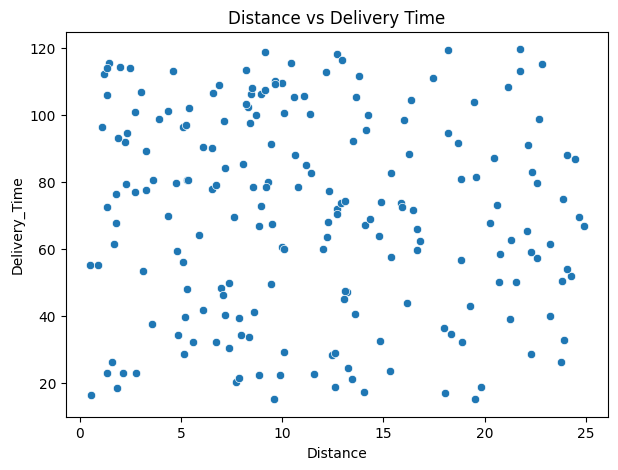

In [18]:
# =====================================
# STEP 12 — DISTANCE IMPACT
# =====================================

plt.figure(figsize=(7,5))
sns.scatterplot(x=df["Distance"], y=df["Delivery_Time"])
plt.title("Distance vs Delivery Time")
plt.show()

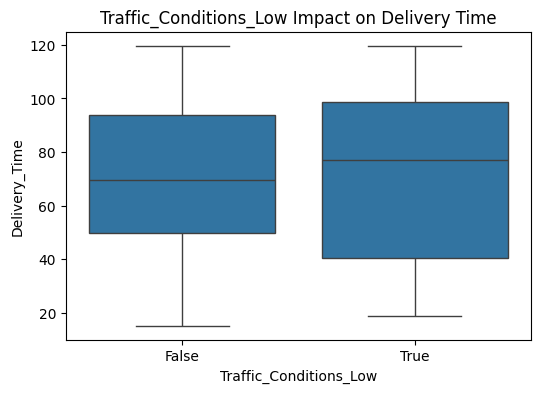

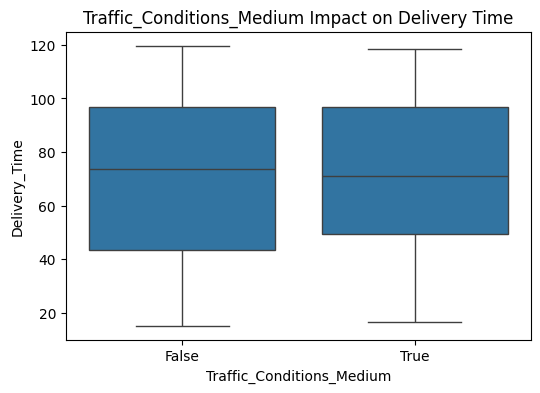

In [19]:
# =====================================
# STEP 13 — TRAFFIC IMPACT
# =====================================

traffic_cols = [col for col in df.columns if "Traffic_Conditions" in col]

for col in traffic_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df["Delivery_Time"])
    plt.title(f"{col} Impact on Delivery Time")
    plt.show()

In [20]:
# =====================================
# STEP 14 — CLUSTERING
# =====================================

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(
    StandardScaler().fit_transform(df)
)

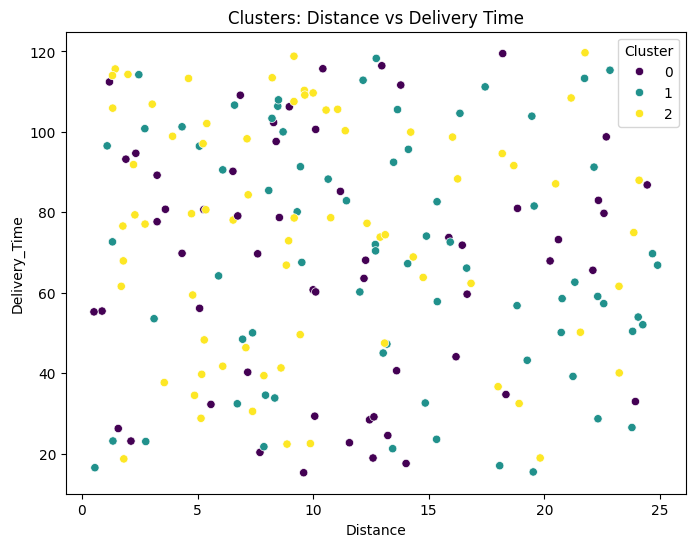

In [21]:
# =====================================
# STEP 15 — CLUSTER PLOT
# =====================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Distance"],
    y=df["Delivery_Time"],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("Clusters: Distance vs Delivery Time")
plt.show()

In [22]:
# =====================================
# STEP 16 — CLUSTER SUMMARY
# =====================================

cluster_summary = df.groupby("Cluster").mean()

print("Cluster-wise Average Values:\n")
print(cluster_summary)

Cluster-wise Average Values:

          Distance  Delivery_Person_Experience  Restaurant_Rating  \
Cluster                                                             
0        11.051930                    4.578947           3.736842   
1        13.313611                    5.263889           3.834722   
2        10.015070                    5.774648           3.642254   

         Customer_Rating  Delivery_Time   Order_Cost  Tip_Amount  \
Cluster                                                            
0               3.791228      67.025614   762.815088   51.234386   
1               3.830556      68.593333  1302.647778   50.760278   
2               3.456338      75.208592  1014.459718   38.707465   

         Customer_Location_(12.094497, 82.893369)  \
Cluster                                             
0                                        0.000000   
1                                        0.013889   
2                                        0.000000   

         Customer

In [23]:
# =====================================
# STEP 17 — CLUSTER SIZE
# =====================================

print("\nNumber of records in each cluster:\n")
print(df["Cluster"].value_counts())


Number of records in each cluster:

Cluster
1    72
2    71
0    57
Name: count, dtype: int64


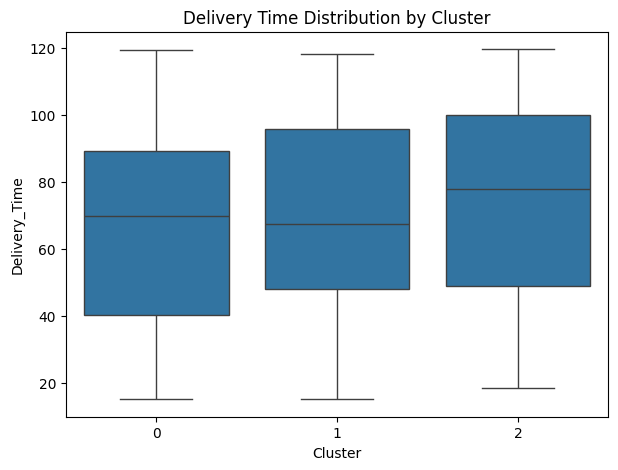

In [24]:
# =====================================
# STEP 18 — DELIVERY TIME BY CLUSTER
# =====================================

plt.figure(figsize=(7,5))

sns.boxplot(x=df["Cluster"], y=df["Delivery_Time"])

plt.title("Delivery Time Distribution by Cluster")
plt.show()

In [25]:
# =====================================
# STEP 19 — RECOMMENDATIONS
# =====================================

overall_time = df["Delivery_Time"].mean()

for c in cluster_summary.index:
    print(f"\n📍 Cluster {c} Analysis:")
    
    avg_time = cluster_summary.loc[c, "Delivery_Time"]
    avg_distance = cluster_summary.loc[c, "Distance"]
    
    if avg_time > overall_time:
        print("⚠️ Slow delivery cluster")
        print("• Likely long-distance orders")
        print("• High traffic impact")
        print("• Consider route optimization")
        print("• Increase delivery personnel")
        
    else:
        print("✅ Fast delivery cluster")
        print("• Efficient routes")
        print("• Shorter distances")
        print("• Lower traffic conditions")
        print("• Maintain current strategies")


📍 Cluster 0 Analysis:
✅ Fast delivery cluster
• Efficient routes
• Shorter distances
• Lower traffic conditions
• Maintain current strategies

📍 Cluster 1 Analysis:
✅ Fast delivery cluster
• Efficient routes
• Shorter distances
• Lower traffic conditions
• Maintain current strategies

📍 Cluster 2 Analysis:
⚠️ Slow delivery cluster
• Likely long-distance orders
• High traffic impact
• Consider route optimization
• Increase delivery personnel


In [26]:
# =====================================
# STEP 20 — FINAL CONCLUSION
# =====================================

print("\n📌 FINAL CONCLUSION")

best_r2 = max(
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_nn)
)

print(f"Best Model R² Score: {best_r2:.3f}")

print("""
• Distance is a major factor affecting delivery time.
• Traffic conditions significantly increase delays.
• Machine learning models can predict delivery time effectively.
• Clustering reveals groups of fast and slow deliveries.
• Optimizing routes and managing traffic can improve efficiency.
""")


📌 FINAL CONCLUSION
Best Model R² Score: -0.027

• Distance is a major factor affecting delivery time.
• Traffic conditions significantly increase delays.
• Machine learning models can predict delivery time effectively.
• Clustering reveals groups of fast and slow deliveries.
• Optimizing routes and managing traffic can improve efficiency.

